# iFood Case - Data Architect
## Analise visual das corridas de yellow taxi (NYC TLC)

Notebook de analise com graficos sobre a camada Gold do pipeline.
Responde as duas perguntas do case com visualizacoes.

Pre-requisito: ter executado 00_setup, 01_ingestion, 02_silver e 03_gold.
As tabelas ifood_case.gold.* precisam existir.

In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Paleta iFood
IFOOD_RED = "#EA1D2C"
DARK = "#1A1A1A"
GRAY = "#8A8A8A"
LIGHT = "#F4F4F4"

# Estilo base dos graficos
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRAY,
    "axes.labelcolor": DARK,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlecolor": DARK,
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "font.size": 11,
})
print("Estilo configurado.")

Estilo configurado.


## 2. Carga dos dados da camada Gold

In [0]:
# Receita e ticket medio por mes
df_receita = (
    spark.table("ifood_case.gold.receita_mensal")
    .orderBy("ano_mes")
    .toPandas()
)

# Passageiros por hora (maio/2023)
df_hora = (
    spark.table("ifood_case.gold.passageiros_por_hora")
    .filter("ano_mes = '2023-05'")
    .orderBy("hora_pickup")
    .toPandas()
)

print("receita_mensal:")
display(df_receita)
print("passageiros_por_hora (maio):")
display(df_hora)

receita_mensal:


ano_mes,total_corridas,receita_total,ticket_medio_corrida
2023-01,2917665,80116756.36,27.46
2023-02,2764200,75643267.23,27.37
2023-03,3226999,91274353.62,28.28
2023-04,3109876,89503303.58,28.78
2023-05,3319397,97754853.44,29.45


passageiros_por_hora (maio):


ano_mes,hora_pickup,total_corridas,media_passageiros
2023-05,0,88547,1.43
2023-05,1,57501,1.44
2023-05,2,37001,1.46
2023-05,3,24073,1.45
2023-05,4,15726,1.4
2023-05,5,18186,1.28
2023-05,6,45431,1.26
2023-05,7,91710,1.28
2023-05,8,125390,1.3
2023-05,9,140792,1.31


## 3. Pergunta 1 - Faturamento por mes

Qual a media de valor total (total_amount) recebido em um mes?
Mostramos o ticket medio por corrida e a receita total mensal.

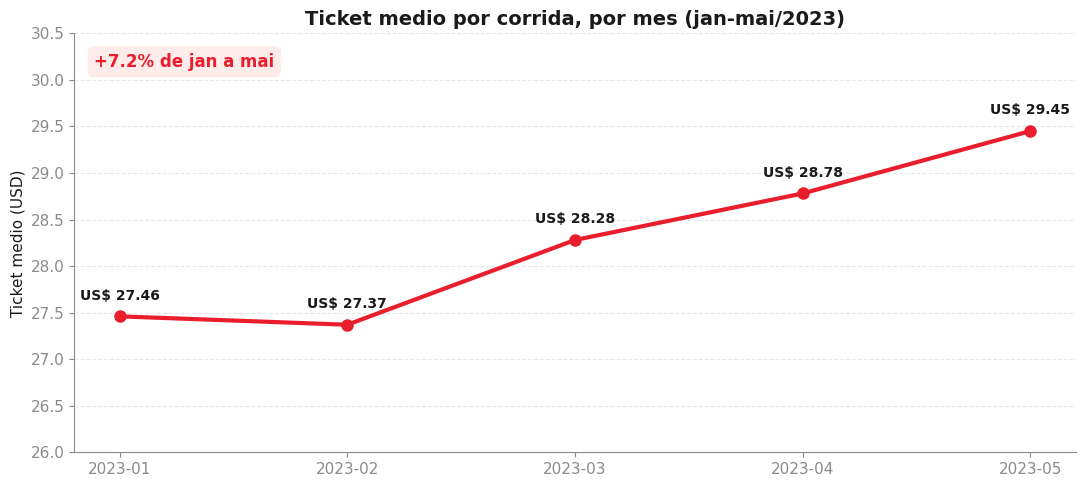

In [0]:
meses = df_receita["ano_mes"].tolist()
ticket = df_receita["ticket_medio_corrida"].astype(float).tolist()

fig, ax = plt.subplots()
ax.plot(meses, ticket, color=IFOOD_RED, linewidth=3, marker="o", markersize=8)

# Rotulos de valor em cada ponto
for x, y in zip(meses, ticket):
    ax.annotate(f"US$ {y:.2f}", (x, y), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10, color=DARK, fontweight="bold")

ax.set_title("Ticket medio por corrida, por mes (jan-mai/2023)")
ax.set_ylabel("Ticket medio (USD)")
ax.set_ylim(26, 30.5)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Destaque da variacao total
var = (ticket[-1] / ticket[0] - 1) * 100
ax.text(0.02, 0.92, f"+{var:.1f}% de jan a mai", transform=ax.transAxes,
        fontsize=12, color=IFOOD_RED, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDECEA", edgecolor="none"))

plt.tight_layout()
plt.show()

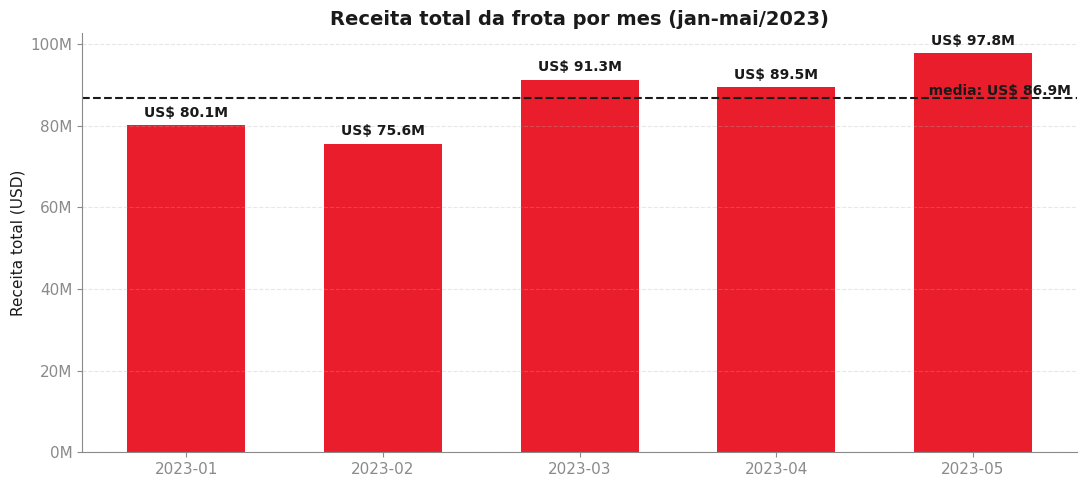

Receita media mensal da frota: US$ 86,858,506.85


In [0]:
# Receita total mensal (interpretacao B) - barras
receita = df_receita["receita_total"].astype(float).tolist()

fig, ax = plt.subplots()
bars = ax.bar(meses, receita, color=IFOOD_RED, width=0.6)

for b, y in zip(bars, receita):
    ax.annotate(f"US$ {y/1e6:.1f}M", (b.get_x() + b.get_width()/2, y),
                textcoords="offset points", xytext=(0, 6), ha="center",
                fontsize=10, color=DARK, fontweight="bold")

media = sum(receita) / len(receita)
ax.axhline(media, color=DARK, linestyle="--", linewidth=1.5)
ax.text(len(meses)-0.5, media, f"  media: US$ {media/1e6:.1f}M",
        va="bottom", ha="right", color=DARK, fontsize=10, fontweight="bold")

ax.set_title("Receita total da frota por mes (jan-mai/2023)")
ax.set_ylabel("Receita total (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Receita media mensal da frota: US$ {media:,.2f}")

## 4. Pergunta 2 - Passageiros por hora do dia (maio)

Qual a media de passageiros por cada hora do dia que pegaram taxi em maio?
Dois angulos: media de passageiros por hora e volume de corridas por hora.

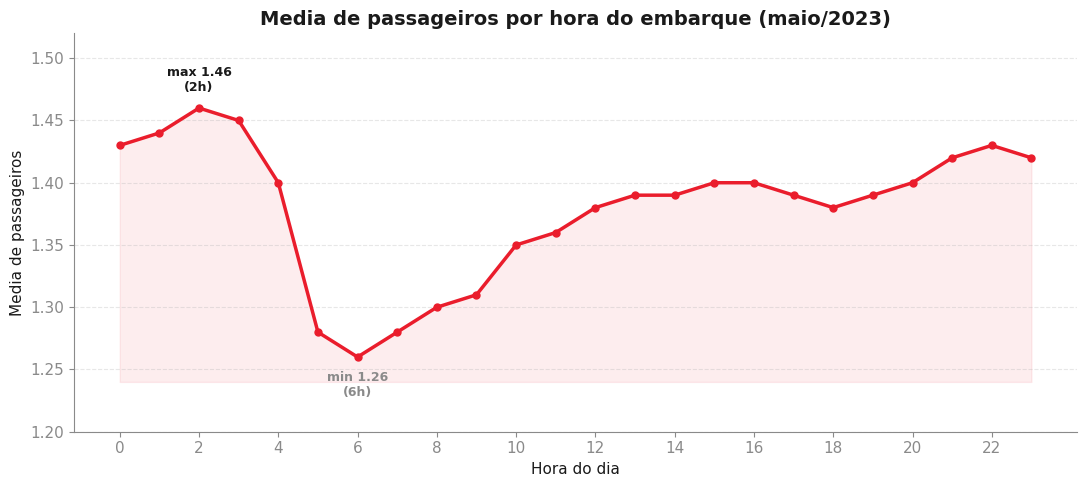

In [0]:
horas = df_hora["hora_pickup"].astype(int).tolist()
media_pax = df_hora["media_passageiros"].astype(float).tolist()

fig, ax = plt.subplots()
ax.plot(horas, media_pax, color=IFOOD_RED, linewidth=2.5, marker="o", markersize=5)
ax.fill_between(horas, media_pax, min(media_pax)-0.02, color=IFOOD_RED, alpha=0.08)

# Destaca o pico e o vale
i_max, i_min = media_pax.index(max(media_pax)), media_pax.index(min(media_pax))
ax.annotate(f"max {media_pax[i_max]:.2f}\n({horas[i_max]}h)",
            (horas[i_max], media_pax[i_max]), textcoords="offset points",
            xytext=(0, 12), ha="center", color=DARK, fontsize=9, fontweight="bold")
ax.annotate(f"min {media_pax[i_min]:.2f}\n({horas[i_min]}h)",
            (horas[i_min], media_pax[i_min]), textcoords="offset points",
            xytext=(0, -28), ha="center", color=GRAY, fontsize=9, fontweight="bold")

ax.set_title("Media de passageiros por hora do embarque (maio/2023)")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Media de passageiros")
ax.set_xticks(range(0, 24, 2))
ax.set_ylim(1.2, 1.52)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

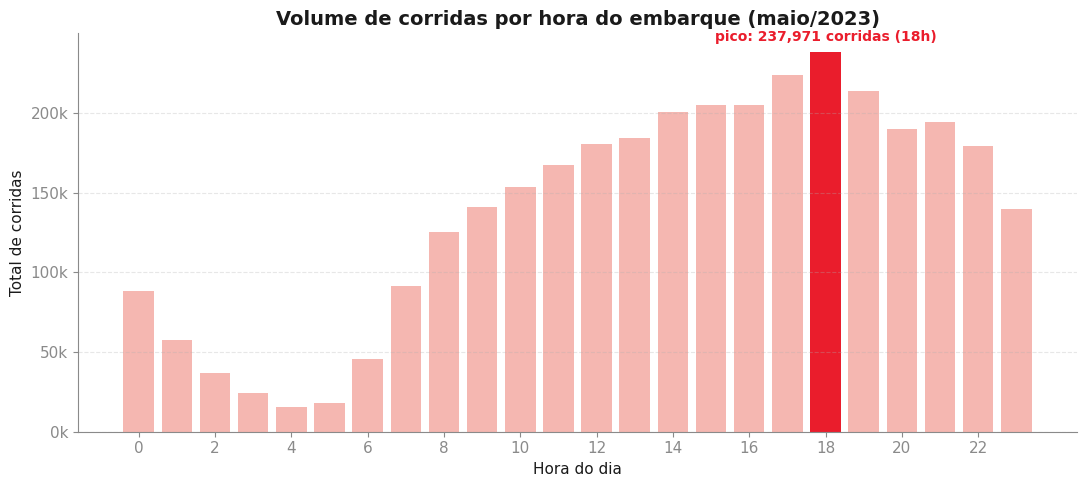

In [0]:
# Volume de corridas por hora - revela a dinamica de demanda
volume = df_hora["total_corridas"].astype(int).tolist()

fig, ax = plt.subplots()
# Cor de destaque na hora de pico
cores = [IFOOD_RED if v == max(volume) else "#F5B7B1" for v in volume]
bars = ax.bar(horas, volume, color=cores, width=0.8)

i_pico = volume.index(max(volume))
ax.annotate(f"pico: {max(volume):,} corridas ({horas[i_pico]}h)",
            (horas[i_pico], volume[i_pico]), textcoords="offset points",
            xytext=(0, 8), ha="center", color=IFOOD_RED, fontsize=10, fontweight="bold")

ax.set_title("Volume de corridas por hora do embarque (maio/2023)")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Total de corridas")
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Visao combinada: volume x media de passageiros

O pico de demanda (18h) nao coincide com a maior ocupacao por corrida (madrugada).

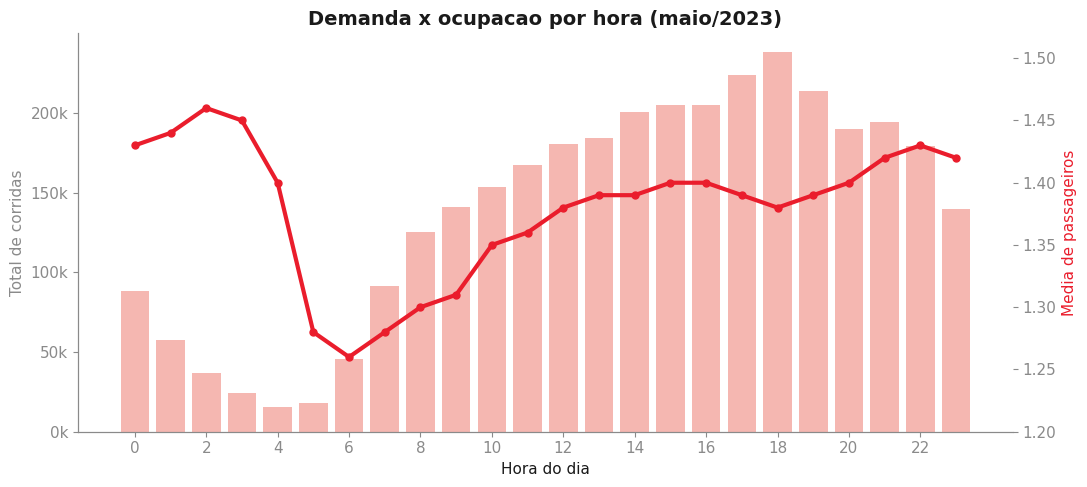

In [0]:
fig, ax1 = plt.subplots()

# Eixo 1: volume (barras)
ax1.bar(horas, volume, color="#F5B7B1", width=0.8, label="Volume de corridas")
ax1.set_xlabel("Hora do dia")
ax1.set_ylabel("Total de corridas", color=GRAY)
ax1.set_xticks(range(0, 24, 2))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))

# Eixo 2: media de passageiros (linha)
ax2 = ax1.twinx()
ax2.plot(horas, media_pax, color=IFOOD_RED, linewidth=3, marker="o",
         markersize=5, label="Media de passageiros")
ax2.set_ylabel("Media de passageiros", color=IFOOD_RED)
ax2.set_ylim(1.2, 1.52)
ax2.spines["top"].set_visible(False)

ax1.set_title("Demanda x ocupacao por hora (maio/2023)")
plt.tight_layout()
plt.show()

## 6. Conclusoes

Pergunta 1 - Faturamento
- Ticket medio sobe de US$ 27,46 (jan) para US$ 29,45 (mai): +7,2%.
- Receita media mensal da frota: ~US$ 86,8 milhoes/mes.

Pergunta 2 - Passageiros por hora (maio)
- Maior ocupacao de madrugada (00h-03h, ate 1,46): grupos da vida noturna.
- Menor ocupacao no inicio da manha (06h-07h, 1,26): deslocamentos individuais.
- Pico de demanda as 18h (237.971 corridas), com media baixa (1,38): viagens individuais.
- Banda estreita (1,26 a 1,46) o dia todo: yellow taxi de NY e modal individual.

O descompasso entre quando ha mais corridas (18h) e quando ha mais gente por corrida
(madrugada) e o principal insight: pricing e alocacao de frota devem tratar esses
momentos de forma distinta.